<a href="https://colab.research.google.com/github/arielabade/carbon/blob/main/gridSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#BATCH SIZE

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 256  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.7443 - loss: 0.6628 - val_accuracy: 0.8235 - val_loss: 0.4785
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.8147 - loss: 0.4385 - val_accuracy: 0.9099 - val_loss: 0.2416
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.9146 - loss: 0.2390 - val_accuracy: 0.7822 - val_loss: 0.3997
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.8580 - loss: 0.2987 - val_accuracy: 0.9262 - val_loss: 0.1845
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.9440 - loss: 0.1606 - val_accuracy: 0.9625 - val_loss: 0.0988
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.9648 - loss: 0.1154 - val_accuracy: 0.9574 - val_loss: 0.1065
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9656 - loss: 0.1137 - val_accuracy: 0.9775 - val_loss: 0.0712
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9690 - loss: 0.1004 - val_accuracy: 0.9775 - val_loss: 0.0562


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 128  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.6867 - loss: 0.6333 - val_accuracy: 0.8711 - val_loss: 0.3371
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9183 - loss: 0.2432 - val_accuracy: 0.9637 - val_loss: 0.1331
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.9665 - loss: 0.1180 - val_accuracy: 0.9775 - val_loss: 0.0740
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9817 - loss: 0.0718 - val_accuracy: 0.9549 - val_loss: 0.1176
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9435 - loss: 0.1466 - val_accuracy: 0.9387 - val_loss: 0.1807
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.9042 - loss: 0.2416 - val_accuracy: 0.9549 - val_loss: 0.1451
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9536 - loss: 0.1520 - val_accuracy: 0.9399 - val_loss: 0.1897
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9619 - loss: 0.1346 - val_accuracy: 0.9750 - val_loss: 0.

Dropout

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 256  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
train_files = file_paths  # Use all files for training

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.6707 - loss: 0.6701 - val_accuracy: 0.8260 - val_loss: 0.5030
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.8204 - loss: 0.4735 - val_accuracy: 0.9174 - val_loss: 0.2376
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9006 - loss: 0.3046 - val_accuracy: 0.9349 - val_loss: 0.1877
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9066 - loss: 0.2693 - val_accuracy: 0.9136 - val_loss: 0.2753
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9195 - loss: 0.2693 - val_accuracy: 0.9412 - val_loss: 0.1883
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.9507 - loss: 0.1955 - val_accuracy: 0.9574 - val_loss: 0.1478
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.9557 - loss: 0.1814 - val_accuracy: 0.9262 - val_loss: 0.2365
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.9342 - loss: 0.2350 - val_accuracy: 0.9474 - val_loss: 0.1792
Epo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 256  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
train_files = file_paths  # Use all files for training

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.3),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.3),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.3),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.6115 - loss: 0.6777 - val_accuracy: 0.8486 - val_loss: 0.5076
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8413 - loss: 0.4509 - val_accuracy: 0.9287 - val_loss: 0.1951
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.9302 - loss: 0.2372 - val_accuracy: 0.9637 - val_loss: 0.1605
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9413 - loss: 0.2143 - val_accuracy: 0.8398 - val_loss: 0.6113
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.8808 - loss: 0.4223 - val_accuracy: 0.9399 - val_loss: 0.1964
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.9463 - loss: 0.2063 - val_accuracy: 0.9675 - val_loss: 0.1250
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9691 - loss: 0.1380 - val_accuracy: 0.9687 - val_loss: 0.1210
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.9619 - loss: 0.1499 - val_accuracy: 0.9700 - val_loss: 0.1072
Epo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 256  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
train_files = file_paths  # Use all files for training

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.4),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.4),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.4),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.6079 - loss: 0.6803 - val_accuracy: 0.8273 - val_loss: 0.5445
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.8246 - loss: 0.4896 - val_accuracy: 0.7209 - val_loss: 0.8897
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8366 - loss: 0.5264 - val_accuracy: 0.8048 - val_loss: 0.5101
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8826 - loss: 0.3620 - val_accuracy: 0.9612 - val_loss: 0.1685
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.9566 - loss: 0.1951 - val_accuracy: 0.9199 - val_loss: 0.2676
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9429 - loss: 0.2223 - val_accuracy: 0.9587 - val_loss: 0.1287
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9393 - loss: 0.1969 - val_accuracy: 0.9650 - val_loss: 0.1157
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.9507 - loss: 0.1649 - val_accuracy: 0.9612 - val_loss: 0.0967
Ep

Epochs (batches 236, dropout 0.2)
*italicized text*

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.6394 - loss: 0.6785 - val_accuracy: 0.8298 - val_loss: 0.5435
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.8068 - loss: 0.4892 - val_accuracy: 0.9449 - val_loss: 0.1864
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.8758 - loss: 0.3982 - val_accuracy: 0.9537 - val_loss: 0.2471
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9308 - loss: 0.2578 - val_accuracy: 0.9599 - val_loss: 0.1474
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.9638 - loss: 0.1503 - val_accuracy: 0.9725 - val_loss: 0.1081
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9694 - loss: 0.1305 - val_accuracy: 0.9750 - val_loss: 0.0892
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.9762 - loss: 0.0922 - val_accuracy: 0.9787 - val_loss: 0.0689
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9793 - loss: 0.0753 - val_accuracy: 0.9812 - val_loss: 0.0616
Epo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 20  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.6590 - loss: 0.6771 - val_accuracy: 0.8310 - val_loss: 0.5161
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8247 - loss: 0.4529 - val_accuracy: 0.9387 - val_loss: 0.1874
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.9395 - loss: 0.2062 - val_accuracy: 0.9637 - val_loss: 0.1365
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9587 - loss: 0.1573 - val_accuracy: 0.9725 - val_loss: 0.1199
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.9666 - loss: 0.1398 - val_accuracy: 0.9537 - val_loss: 0.1478
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9410 - loss: 0.1873 - val_accuracy: 0.9462 - val_loss: 0.1535
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9391 - loss: 0.1963 - val_accuracy: 0.8298 - val_loss: 0.3967
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.9024 - loss: 0.2767 - val_accuracy: 0.9775 - val_loss: 0.1043
Epo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 40  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.6122 - loss: 0.6743 - val_accuracy: 0.8511 - val_loss: 0.5095
Epoch 2/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.8502 - loss: 0.4368 - val_accuracy: 0.9387 - val_loss: 0.1689
Epoch 3/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9453 - loss: 0.2173 - val_accuracy: 0.8673 - val_loss: 0.4179
Epoch 4/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8496 - loss: 0.4526 - val_accuracy: 0.9412 - val_loss: 0.2036
Epoch 5/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9407 - loss: 0.2198 - val_accuracy: 0.9625 - val_loss: 0.1286
Epoch 6/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9610 - loss: 0.1488 - val_accuracy: 0.9825 - val_loss: 0.0786
Epoch 7/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9664 - loss: 0.1336 - val_accuracy: 0.9474 - val_loss: 0.1784
Epoch 8/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9547 - loss: 0.1645 - val_accuracy: 0.9812 - val_loss: 0.0696
Epo

In [ ]:
# Função de ativação

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


In [ ]:
# Hidden Layers

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.6313 - loss: 0.6813 - val_accuracy: 0.8135 - val_loss: 0.5453
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.8107 - loss: 0.4859 - val_accuracy: 0.9324 - val_loss: 0.2120
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 138s 5s/step - accuracy: 0.9285 - loss: 0.2297 - val_accuracy: 0.9074 - val_loss: 0.2147
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9182 - loss: 0.2097 - val_accuracy: 0.9499 - val_loss: 0.1426
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9420 - loss: 0.1918 - val_accuracy: 0.9212 - val_loss: 0.2808
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9348 - loss: 0.2047 - val_accuracy: 0.9549 - val_loss: 0.1104
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9159 - loss: 0.2252 - val_accuracy: 0.8974 - val_loss: 0.3227
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.8763 - loss: 0.3498 - val_accuracy: 0.9299 - val_loss: 0.1912
Ep

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.6160 - loss: 0.6624 - val_accuracy: 0.8761 - val_loss: 0.3448
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 144s 6s/step - accuracy: 0.9082 - loss: 0.2743 - val_accuracy: 0.9599 - val_loss: 0.1572
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 144s 6s/step - accuracy: 0.9499 - loss: 0.1875 - val_accuracy: 0.9625 - val_loss: 0.1220
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.9497 - loss: 0.1927 - val_accuracy: 0.8448 - val_loss: 0.3633
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.8885 - loss: 0.3036 - val_accuracy: 0.9637 - val_loss: 0.1708
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 145s 6s/step - accuracy: 0.9682 - loss: 0.1597 - val_accuracy: 0.9111 - val_loss: 0.2983
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.9256 - loss: 0.2467 - val_accuracy: 0.8961 - val_loss: 0.2728
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.9463 - loss: 0.1867 - val_accuracy: 0.9449 - val_loss: 0.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(64)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 385s 15s/step - accuracy: 0.6277 - loss: 0.6389 - val_accuracy: 0.9086 - val_loss: 0.3669
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 326s 13s/step - accuracy: 0.9181 - loss: 0.2647 - val_accuracy: 0.9412 - val_loss: 0.1955
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 322s 12s/step - accuracy: 0.8625 - loss: 0.4560 - val_accuracy: 0.9399 - val_loss: 0.2319
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 323s 12s/step - accuracy: 0.9437 - loss: 0.2089 - val_accuracy: 0.9650 - val_loss: 0.1405
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 325s 12s/step - accuracy: 0.9655 - loss: 0.1480 - val_accuracy: 0.9737 - val_loss: 0.1000
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 401s 13s/step - accuracy: 0.9185 - loss: 0.3017 - val_accuracy: 0.8836 - val_loss: 0.4602
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 334s 13s/step - accuracy: 0.9104 - loss: 0.3155 - val_accuracy: 0.9687 - val_loss: 0.1630
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 335s 13s/step - accuracy: 0.9766 - loss: 0.1320 - val_accuracy: 0.9700 - val_

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(128)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


FileNotFoundError: [Errno 2] No such file or directory: '/content/PPIAFIX2_test_CORRECTED.csv'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(256, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(256)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
# test_file = random.choice(file_paths)  # Comentado
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model with Dropout
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(512, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(512)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


In [ ]:
# Dense Layers

In [ ]:
# Optimazer

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 10000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 246  # Adjust batch size if needed
epochs = 10  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Select one file randomly for testing
train_files = file_paths  # Usar todos os arquivos para treinamento

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Function to build the model
def build_model(optimizer_name):
    vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
    embedding_dim = 32  # Can be adjusted

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(64)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # For binary classification
    ])

    # Compile the model with the selected optimizer
    model.compile(optimizer=optimizer_name, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Optimizers to test
optimizers = {
    'Adam': 'adam',
    'RMSprop': 'rmsprop',
    'AdaGrad': 'adagrad'
}

# Loop through optimizers and train the model
for optimizer_name, optimizer in optimizers.items():
    print(f"\nTraining with {optimizer_name} optimizer...")

    # Build the model with the current optimizer
    model = build_model(optimizer)

    # Train the model
    model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

    # Evaluate the model on the validation data
    val_loss, val_accuracy = model.evaluate(validation_generator)
    print(f'Validation Accuracy with {optimizer_name}: {val_accuracy*100:.2f}%')

    # 7. Load the test data from all files and evaluate
    for test_file in file_paths:
        test_data = pd.read_csv(test_file)
        test_sequences = test_data['sequence'].values
        test_labels = test_data['exon_intron_flag'].values

        # Tokenize and pad test sequences
        encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
        padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

        # Evaluate the model on the test data
        test_predictions = model.predict(padded_test_sequences)
        test_predictions = (test_predictions > 0.5).astype(int)

        # Calculate test metrics
        test_accuracy = accuracy_score(test_labels, test_predictions)
        test_precision = precision_score(test_labels, test_predictions)
        test_sensitivity = recall_score(test_labels, test_predictions)
        test_f1_score = f1_score(test_labels, test_predictions)

        print(f'Results for {test_file} with {optimizer_name}:')
        print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
        print(f'Test Precision: {test_precision:.2f}')
        print(f'Test Sensitivity: {test_sensitivity:.2f}')
        print(f'Test F1 Score: {test_f1_score:.2f}')
        print('---')

    # 8. Calculate percentage of exons and introns in validation and test sets
    exons_val = np.sum(y_val == 1)
    introns_val = np.sum(y_val == 0)
    total_val = len(y_val)

    exons_val_pct = (exons_val / total_val) * 100
    introns_val_pct = (introns_val / total_val) * 100

    print(f'Validation Set with {optimizer_name}: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []  # Inicialização correta das variáveis
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Calculando as médias totais
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Adicionando as métricas totais ao DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]]
})

# Concatenando as métricas totais ao DataFrame de resultados
results_df = pd.concat([results_df, total_metrics], ignore_index=True)
print("Results with Total Metrics:")
print(results_df)

# Avaliação combinada
combined_test_labels = np.concatenate([test_labels for test_file in file_paths_train])
combined_test_sequences = np.concatenate([padded_test_sequences for test_file in file_paths_train])
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

# Calculando métricas combinadas
test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'Test Accuracy (combined files): {test_accuracy * 100:.2f}%')
print(f'Test Precision (combined files): {test_precision:.2f}')
print(f'Test Sensitivity (combined files): {test_sensitivity:.2f}')
print(f'Test F1 Score (combined files): {test_f1_score:.2f}')

# Salvando o modelo treinado
model.save("/content/lstm_model.h5")
print("Modelo salvo como lstm_model.h5")

# Montando o Google Drive e copiando o modelo para lá
from google.colab import drive
drive.mount('/content/drive')
!cp /content/lstm_model.h5 /content/drive/MyDrive/lstm_model.h5
print("Modelo salvo no Google Drive como lstm_model.h5")

import matplotlib.pyplot as plt

# Treinamento do modelo, armazenando o histórico para criar os gráficos
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda e acurácia
def plot_history(history):
    # Gráfico de Perda (Loss)
    plt.figure(figsize=(14, 5))

    # Subplot para Perda
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Subplot para Acurácia
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Chamando a função para plotar os gráficos
plot_history(history)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 392s 769ms/step - accuracy: 0.7994 - loss: 0.3930 - val_accuracy: 0.9659 - val_loss: 0.1102
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 379s 759ms/step - accuracy: 0.9199 - loss: 0.2028 - val_accuracy: 0.9167 - val_loss: 0.2443
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 380s 761ms/step - accuracy: 0.9633 - loss: 0.1015 - val_accuracy: 0.9849 - val_loss: 0.0439
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 393s 787ms/step - accuracy: 0.9821 - loss: 0.0522 - val_accuracy: 0.9869 - val_loss: 0.0337
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 382s 765ms/step - accuracy: 0.9853 - loss: 0.0458 - val_accuracy: 0.9859 - val_loss: 0.0382
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 386s 774ms/step - accuracy: 0.9898 - loss: 0.0342 - val_accuracy: 0.9880 - val_loss: 0.0358
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 384s 771ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9920 - val_loss: 0.0281
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 398s 799ms/step - accuracy: 0.9926 - loss: 0.02

Test Accuracy (combined files): 96.70%
Test Precision (combined files): 0.94
Test Sensitivity (combined files): 1.00
Test F1 Score (combined files): 0.97
Modelo salvo como lstm_model.h5
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo salvo no Google Drive como lstm_model.h5


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 417s 819ms/step - accuracy: 0.7961 - loss: 0.4571 - val_accuracy: 0.9508 - val_loss: 0.2170
Epoch 2/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 391s 783ms/step - accuracy: 0.9500 - loss: 0.1675 - val_accuracy: 0.9819 - val_loss: 0.0797
Epoch 3/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 364s 729ms/step - accuracy: 0.9534 - loss: 0.1228 - val_accuracy: 0.9327 - val_loss: 0.1326
Epoch 4/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 392s 748ms/step - accuracy: 0.9072 - loss: 0.2138 - val_accuracy: 0.9438 - val_loss: 0.1194
Epoch 5/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 366s 733ms/step - accuracy: 0.9532 - loss: 0.1222 - val_accuracy: 0.9729 - val_loss: 0.0728
Epoch 6/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 362s 725ms/step - accuracy: 0.9688 - loss: 0.0810 - val_accuracy: 0.9779 - val_loss: 0.0572
Epoch 7/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 380s 722ms/step - accuracy: 0.9745 - loss: 0.0680 - val_accuracy: 0.9890 - val_loss: 0.0351
Epoch 8/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 381s 720ms/step - accuracy: 0.9806 - loss: 0.06

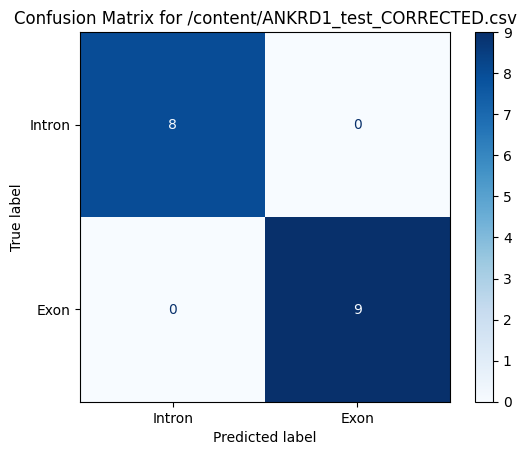

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step


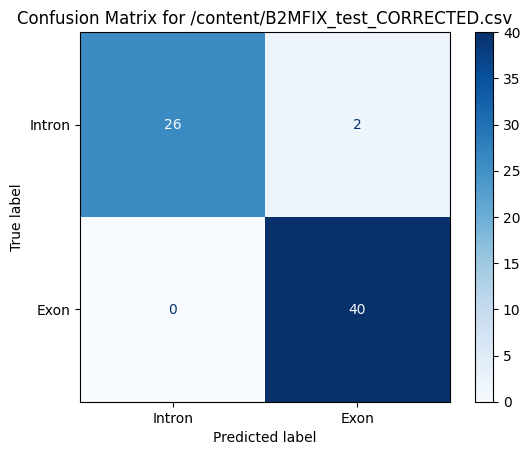

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step


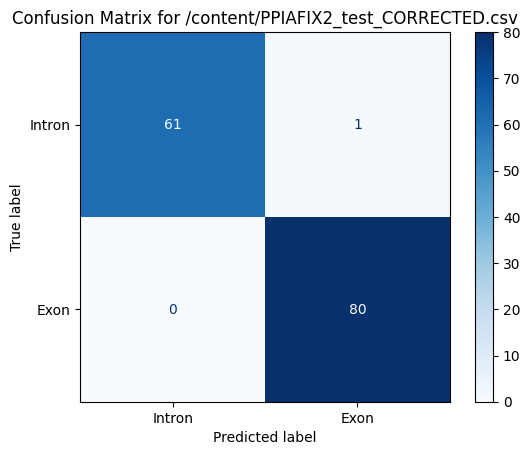

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step


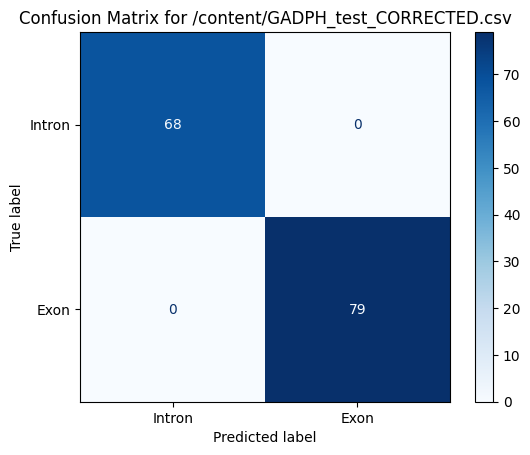

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


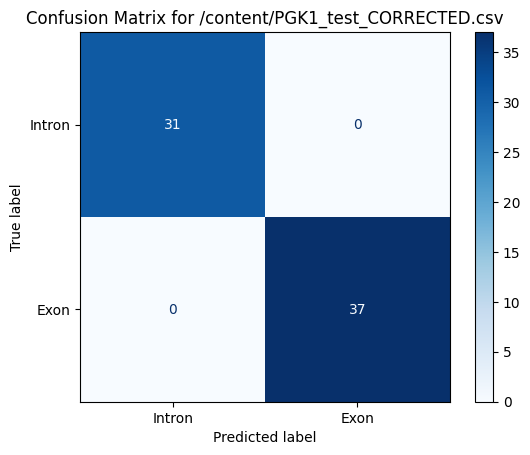

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step


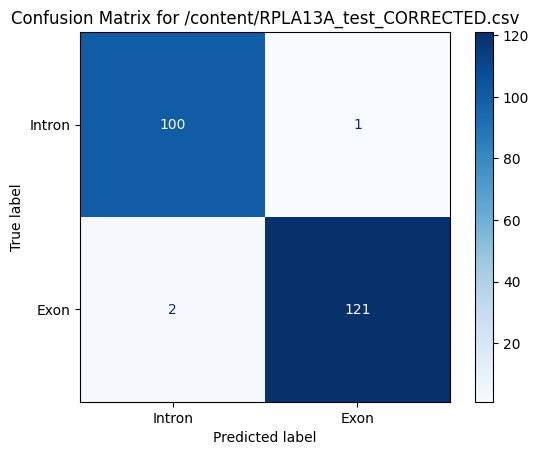

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 38s 158ms/step


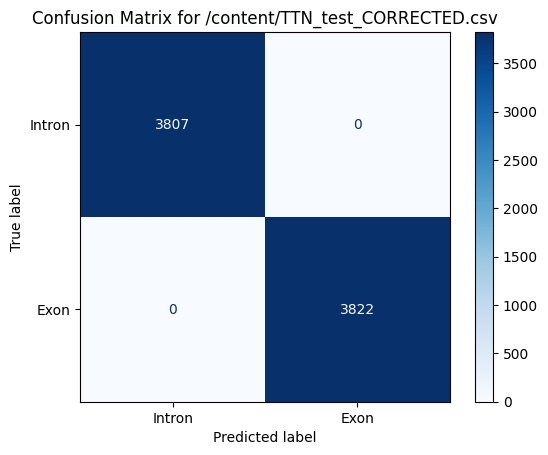

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step


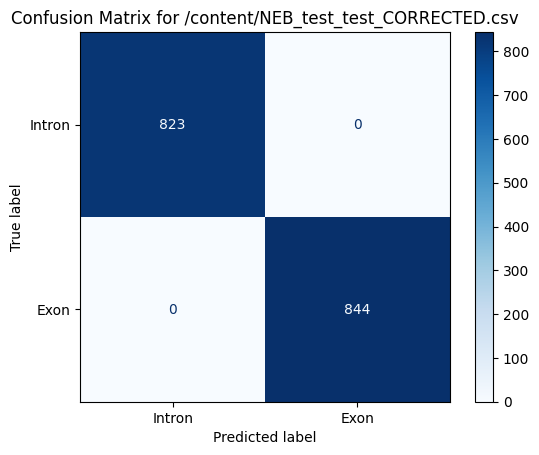

                                   File  Validation ACC  Validation PRE  \
0    /content/ANKRD1_test_CORRECTED.csv       99.899598        0.998039   
1    /content/B2MFIX_test_CORRECTED.csv       99.899598        0.998039   
2  /content/PPIAFIX2_test_CORRECTED.csv       99.899598        0.998039   
3     /content/GADPH_test_CORRECTED.csv       99.899598        0.998039   
4      /content/PGK1_test_CORRECTED.csv       99.899598        0.998039   
5   /content/RPLA13A_test_CORRECTED.csv       99.899598        0.998039   
6       /content/TTN_test_CORRECTED.csv       99.899598        0.998039   
7  /content/NEB_test_test_CORRECTED.csv       99.899598        0.998039   

   Validation SEN  Validation F1S    Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0        0.999019  100.000000  1.000000   1.00000  1.000000  
1             1.0        0.999019   97.058824  0.952381   1.00000  0.975610  
2             1.0        0.999019   99.295775  0.987654   1.00000  0.993789  
3           

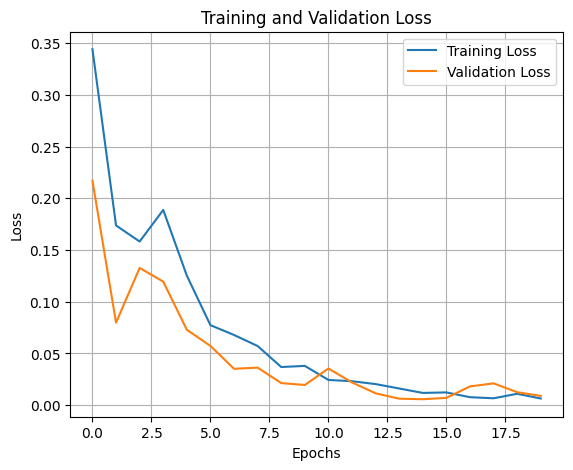

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 20
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e armazenamento do histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Salvando o modelo treinado
model.save("/content/lstm_modelPLOTTED.h5")
print("Modelo salvo como lstm_model.h5")

# Plotando o histórico de treinamento
plot_history(history)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 360s 721ms/step - accuracy: 0.9985 - loss: 0.0049 - val_accuracy: 0.9960 - val_loss: 0.0222
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 379s 716ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9950 - val_loss: 0.0304
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 383s 717ms/step - accuracy: 0.9971 - loss: 0.0110 - val_accuracy: 0.9970 - val_loss: 0.0169
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 362s 726ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9970 - val_loss: 0.0223
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 380s 721ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9970 - val_loss: 0.0230
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 360s 721ms/step - accuracy: 0.9992 - loss: 0.0033 - val_accuracy: 0.9970 - val_loss: 0.0133
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 361s 724ms/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 0.9970 - val_loss: 0.0127
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 383s 726ms/step - accuracy: 0.9988 - loss: 0.00

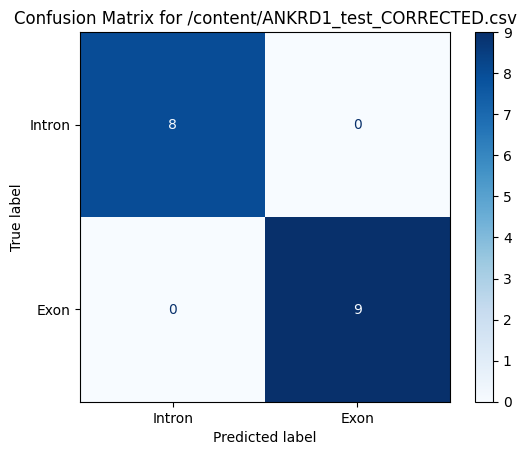

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


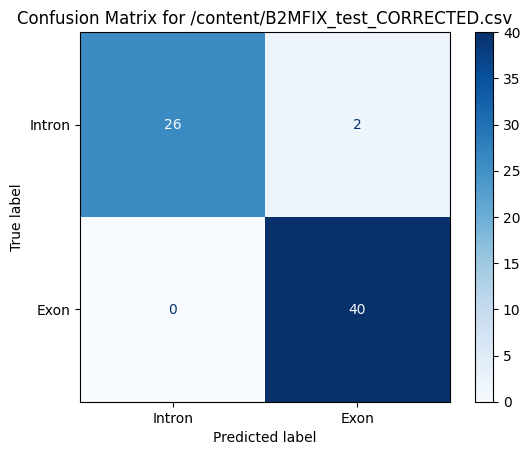

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


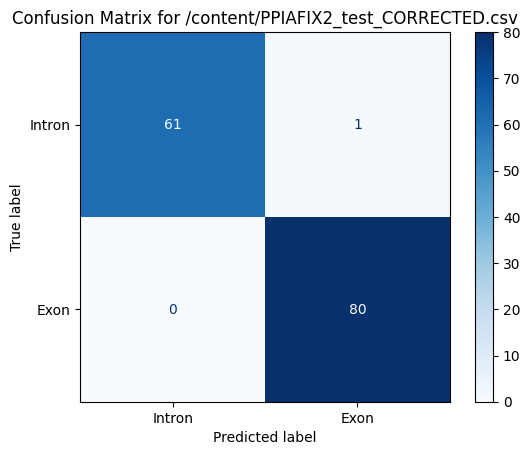

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step


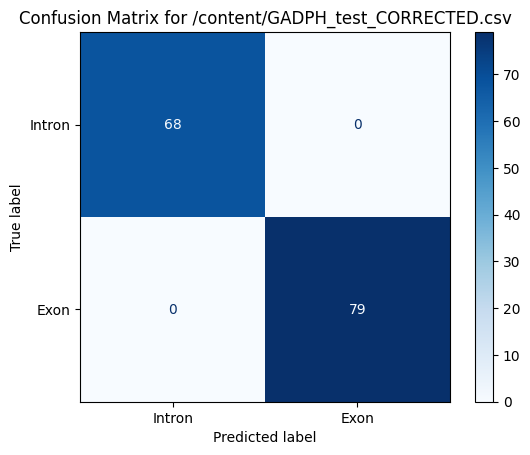

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


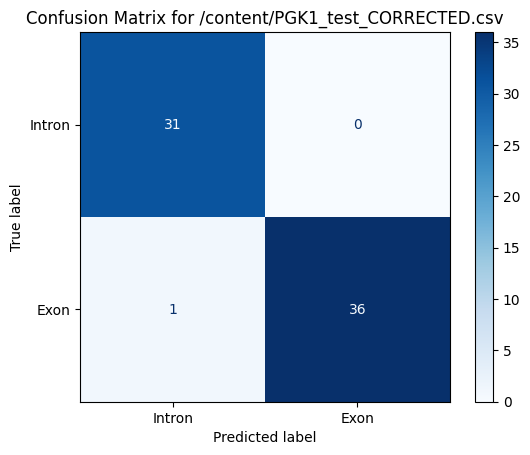

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


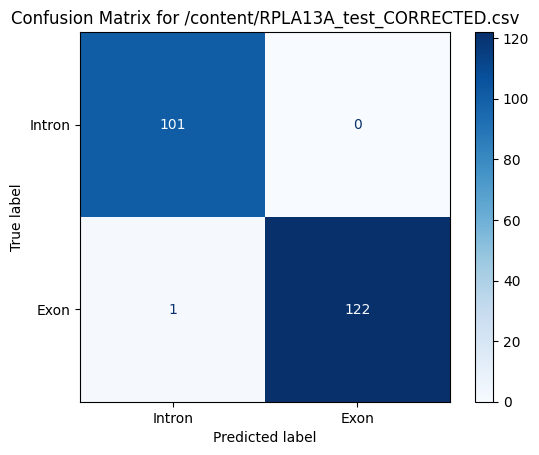

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step


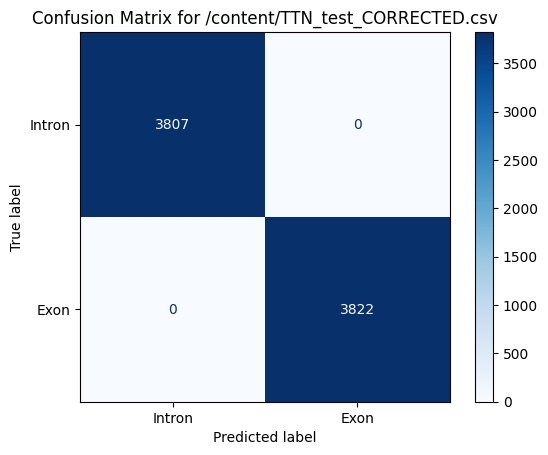

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step


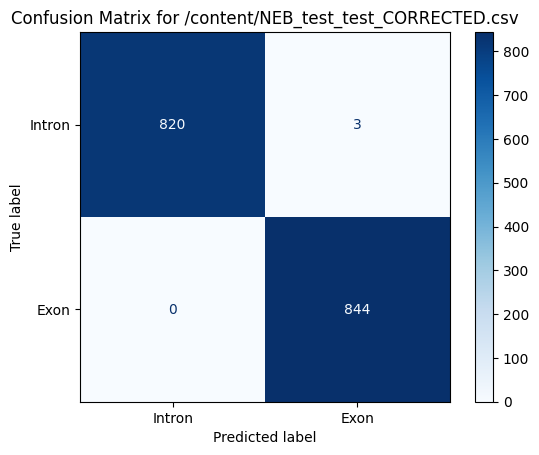

                                   File  Validation ACC  Validation PRE  \
0    /content/ANKRD1_test_CORRECTED.csv       99.698795        0.994141   
1    /content/B2MFIX_test_CORRECTED.csv       99.698795        0.994141   
2  /content/PPIAFIX2_test_CORRECTED.csv       99.698795        0.994141   
3     /content/GADPH_test_CORRECTED.csv       99.698795        0.994141   
4      /content/PGK1_test_CORRECTED.csv       99.698795        0.994141   
5   /content/RPLA13A_test_CORRECTED.csv       99.698795        0.994141   
6       /content/TTN_test_CORRECTED.csv       99.698795        0.994141   
7  /content/NEB_test_test_CORRECTED.csv       99.698795        0.994141   

   Validation SEN  Validation F1S    Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0        0.997062  100.000000  1.000000  1.000000  1.000000  
1             1.0        0.997062   97.058824  0.952381  1.000000  0.975610  
2             1.0        0.997062   99.295775  0.987654  1.000000  0.993789  
3           

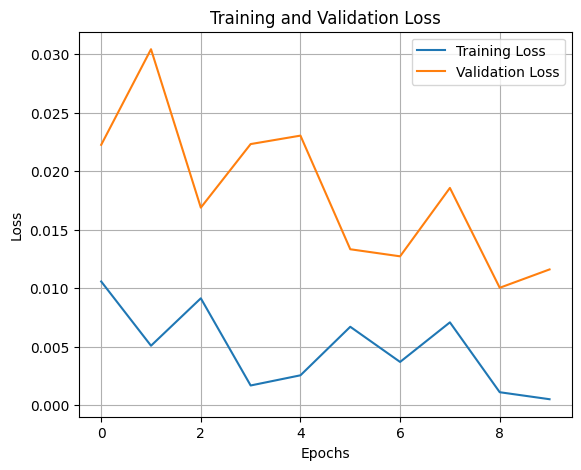

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

# Construção do modelo Bidirectional LSTM com tanh
model_tanh = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='tanh'),  # Função de ativação tanh
    Dense(1, activation='sigmoid')
])

model_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e armazenamento do histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)


# Plotando o histórico de treinamento
plot_history(history)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 438s 852ms/step - accuracy: 0.7295 - loss: 0.5348 - val_accuracy: 0.8363 - val_loss: 0.3879
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 390s 750ms/step - accuracy: 0.9056 - loss: 0.2517 - val_accuracy: 0.9608 - val_loss: 0.1361
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 376s 754ms/step - accuracy: 0.9551 - loss: 0.1440 - val_accuracy: 0.9779 - val_loss: 0.0928
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 361s 723ms/step - accuracy: 0.9588 - loss: 0.1327 - val_accuracy: 0.9779 - val_loss: 0.0791
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 382s 723ms/step - accuracy: 0.9692 - loss: 0.0949 - val_accuracy: 0.9729 - val_loss: 0.0939
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 364s 729ms/step - accuracy: 0.9639 - loss: 0.1047 - val_accuracy: 0.9739 - val_loss: 0.0764
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 379s 724ms/step - accuracy: 0.9740 - loss: 0.0751 - val_accuracy: 0.9558 - val_loss: 0.1036
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 359s 720ms/step - accuracy: 0.9689 - loss: 0.08

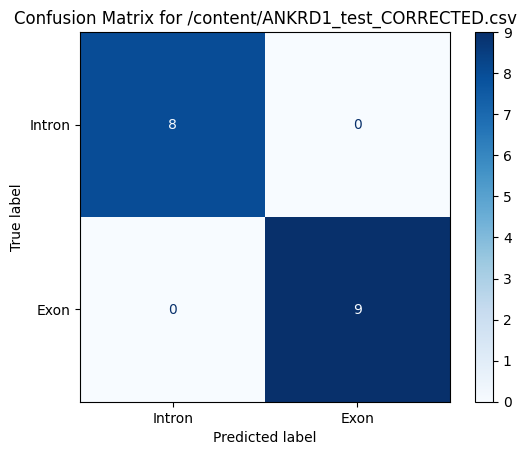

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step


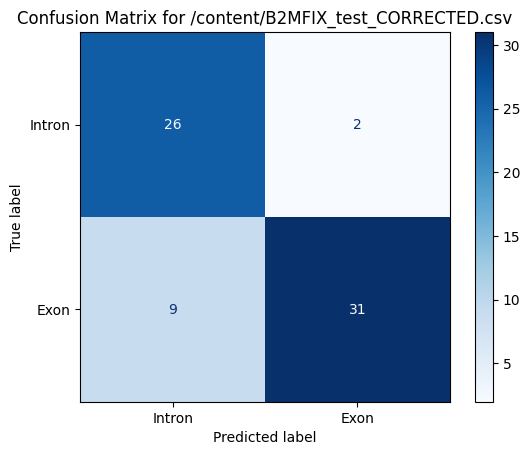

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step


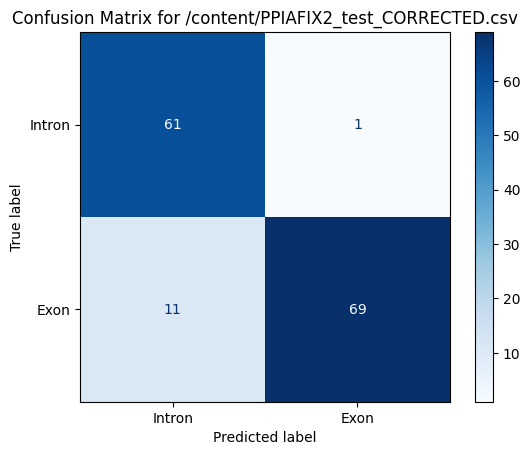

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step


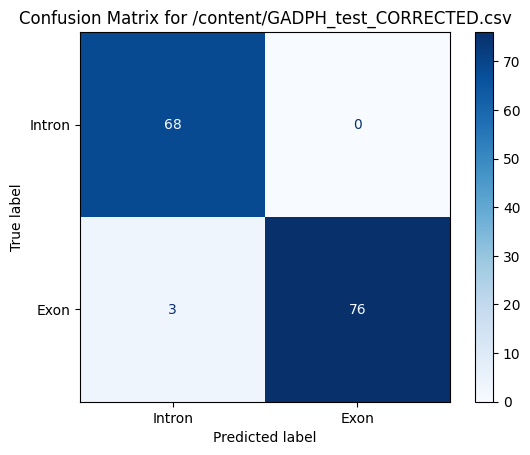

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


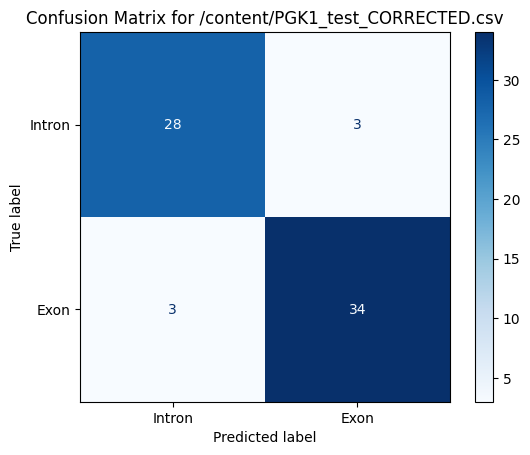

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


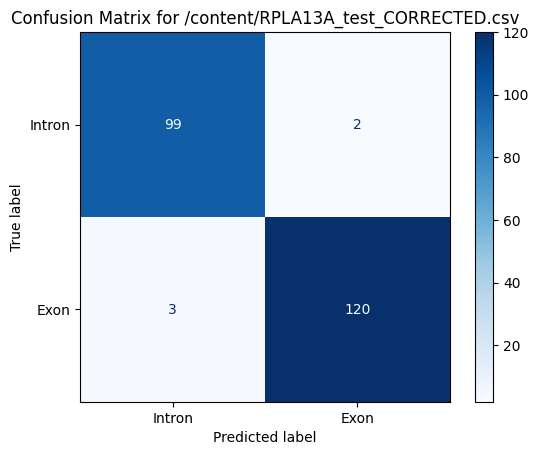

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 38s 161ms/step


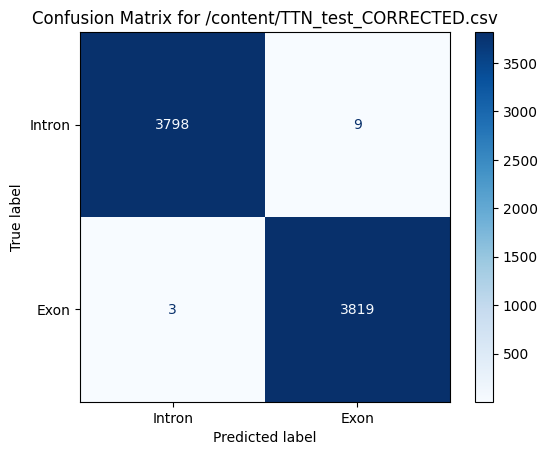

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step


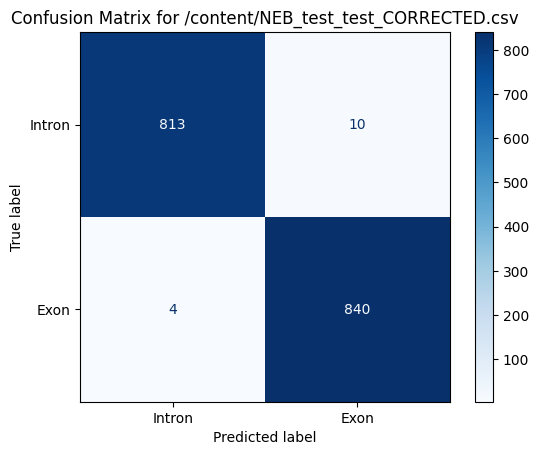

                                   File  Validation ACC  Validation PRE  \
0    /content/ANKRD1_test_CORRECTED.csv       99.297189        0.994094   
1    /content/B2MFIX_test_CORRECTED.csv       99.297189        0.994094   
2  /content/PPIAFIX2_test_CORRECTED.csv       99.297189        0.994094   
3     /content/GADPH_test_CORRECTED.csv       99.297189        0.994094   
4      /content/PGK1_test_CORRECTED.csv       99.297189        0.994094   
5   /content/RPLA13A_test_CORRECTED.csv       99.297189        0.994094   
6       /content/TTN_test_CORRECTED.csv       99.297189        0.994094   
7  /content/NEB_test_test_CORRECTED.csv       99.297189        0.994094   

   Validation SEN  Validation F1S    Test ACC  Test PRE  Test SEN  Test F1S  
0        0.992141        0.993117  100.000000  1.000000  1.000000  1.000000  
1        0.992141        0.993117   83.823529  0.939394  0.775000  0.849315  
2        0.992141        0.993117   91.549296  0.985714  0.862500  0.920000  
3        0.9

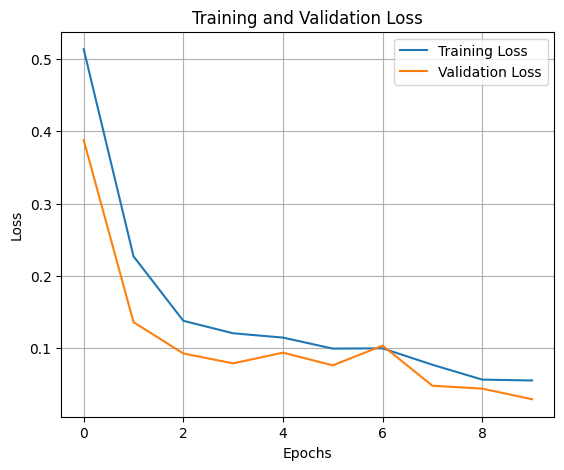

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

# Construção do modelo Bidirectional LSTM com sigmoid
model_sigmoid = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='sigmoid'),  # Usando sigmoid ao invés de relu aqui
    Dense(1, activation='sigmoid')    # Saída com sigmoid para classificação binária
])

model_sigmoid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e armazenamento do histórico
history = model_sigmoid.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model_sigmoid.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model_sigmoid.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Plotando o histórico de treinamento
plot_history(history)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 366s 719ms/step - accuracy: 0.7702 - loss: 0.4650 - val_accuracy: 0.9598 - val_loss: 0.1493
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 381s 717ms/step - accuracy: 0.9415 - loss: 0.1896 - val_accuracy: 0.9548 - val_loss: 0.1468
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 357s 716ms/step - accuracy: 0.9581 - loss: 0.1397 - val_accuracy: 0.9679 - val_loss: 0.1181
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 357s 716ms/step - accuracy: 0.9679 - loss: 0.1112 - val_accuracy: 0.9729 - val_loss: 0.1083
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 359s 719ms/step - accuracy: 0.9547 - loss: 0.1502 - val_accuracy: 0.9829 - val_loss: 0.0521
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 378s 711ms/step - accuracy: 0.9778 - loss: 0.0798 - val_accuracy: 0.9799 - val_loss: 0.0780
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 387s 720ms/step - accuracy: 0.9756 - loss: 0.0792 - val_accuracy: 0.9849 - val_loss: 0.0490
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 379s 714ms/step - accuracy: 0.9783 - loss: 0.06

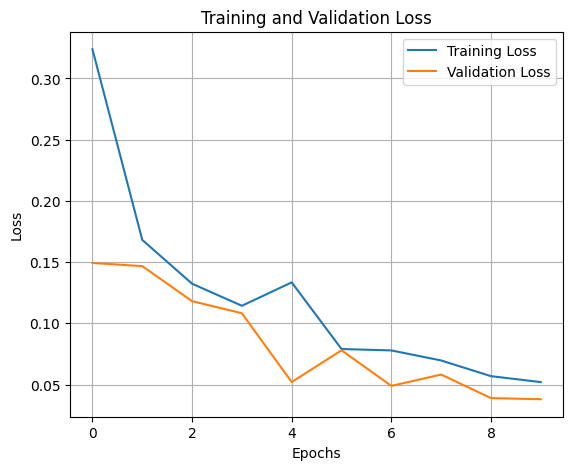

NameError: name 'model' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

# Modelo Bidirectional LSTM com RMSprop
model_rmsprop = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

# Compilar o modelo com RMSprop
model_rmsprop.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento com RMSprop
history_rmsprop = model_rmsprop.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Plotar histórico do modelo RMSprop
plot_history(history_rmsprop)


# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e armazenamento do histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)


# Plotando o histórico de treinamento
plot_history(history)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 441s 855ms/step - accuracy: 0.6112 - loss: 0.6357 - val_accuracy: 0.8504 - val_loss: 0.5798
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 415s 803ms/step - accuracy: 0.7656 - loss: 0.4575 - val_accuracy: 0.9167 - val_loss: 0.2472
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 442s 804ms/step - accuracy: 0.8897 - loss: 0.2592 - val_accuracy: 0.9367 - val_loss: 0.1440
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 399s 799ms/step - accuracy: 0.9135 - loss: 0.2099 - val_accuracy: 0.9618 - val_loss: 0.0863
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 439s 792ms/step - accuracy: 0.9423 - loss: 0.1563 - val_accuracy: 0.9518 - val_loss: 0.0979
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 438s 785ms/step - accuracy: 0.9398 - loss: 0.1533 - val_accuracy: 0.9669 - val_loss: 0.0861
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 394s 790ms/step - accuracy: 0.9609 - loss: 0.1039 - val_accuracy: 0.9488 - val_loss: 0.1323
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 441s 789ms/step - accuracy: 0.9550 - loss: 0.11

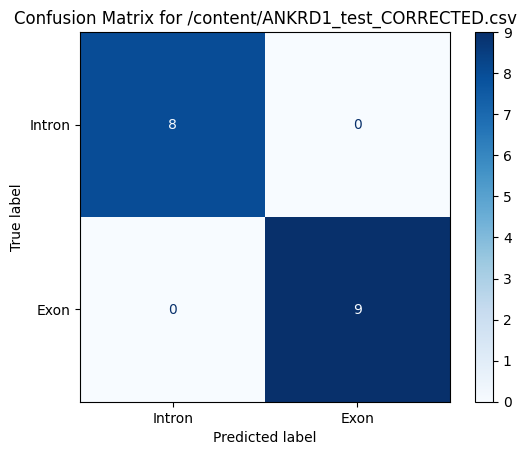

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


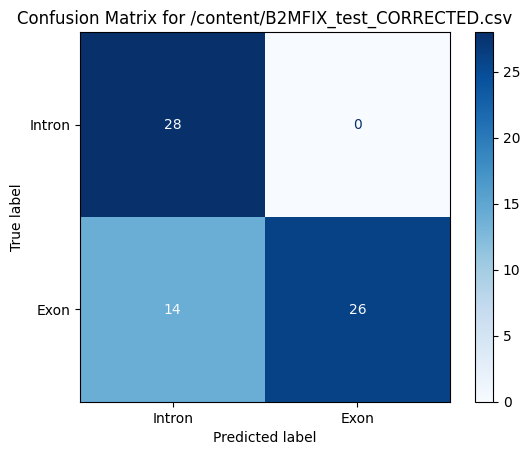

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step


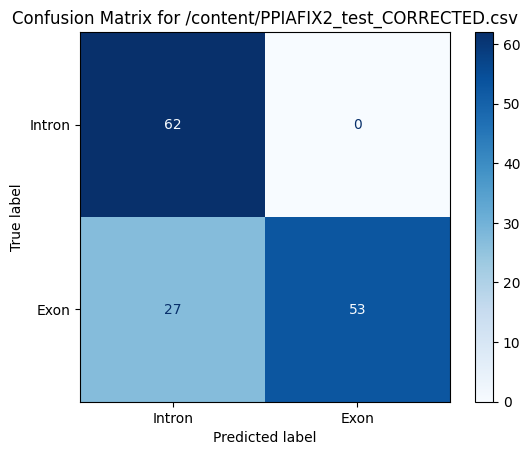

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step


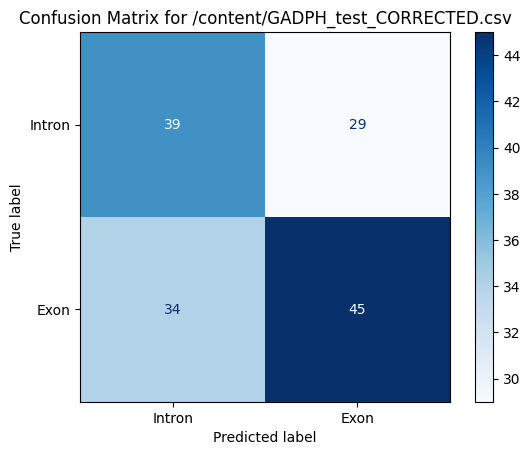

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step


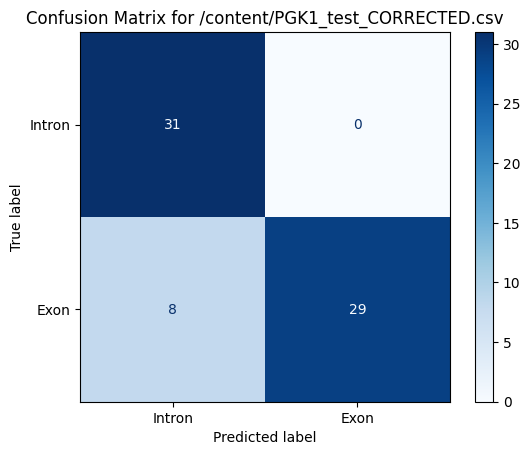

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step


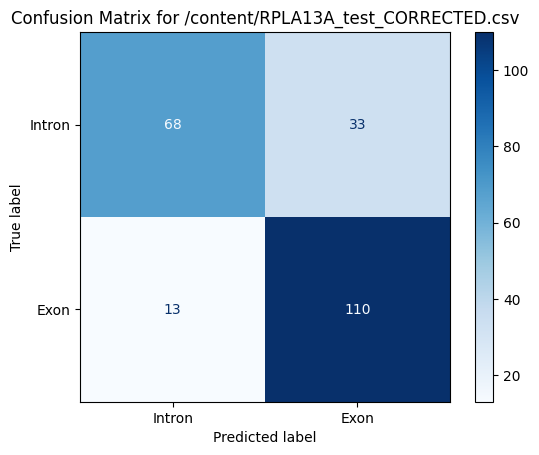

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step


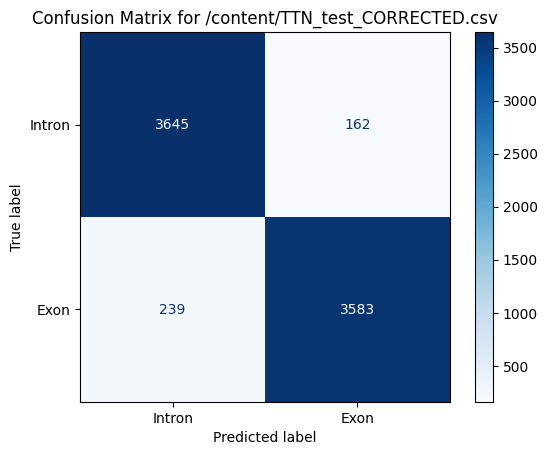

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step


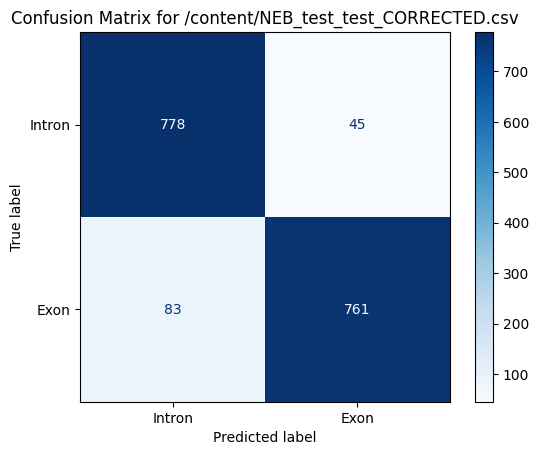

                                   File  Validation ACC  Validation PRE  \
0    /content/ANKRD1_test_CORRECTED.csv       94.277108        0.950199   
1    /content/B2MFIX_test_CORRECTED.csv       94.277108        0.950199   
2  /content/PPIAFIX2_test_CORRECTED.csv       94.277108        0.950199   
3     /content/GADPH_test_CORRECTED.csv       94.277108        0.950199   
4      /content/PGK1_test_CORRECTED.csv       94.277108        0.950199   
5   /content/RPLA13A_test_CORRECTED.csv       94.277108        0.950199   
6       /content/TTN_test_CORRECTED.csv       94.277108        0.950199   
7  /content/NEB_test_test_CORRECTED.csv       94.277108        0.950199   

   Validation SEN  Validation F1S    Test ACC  Test PRE  Test SEN  Test F1S  
0        0.937132         0.94362  100.000000  1.000000  1.000000  1.000000  
1        0.937132         0.94362   79.411765  1.000000  0.650000  0.787879  
2        0.937132         0.94362   80.985915  1.000000  0.662500  0.796992  
3        0.9

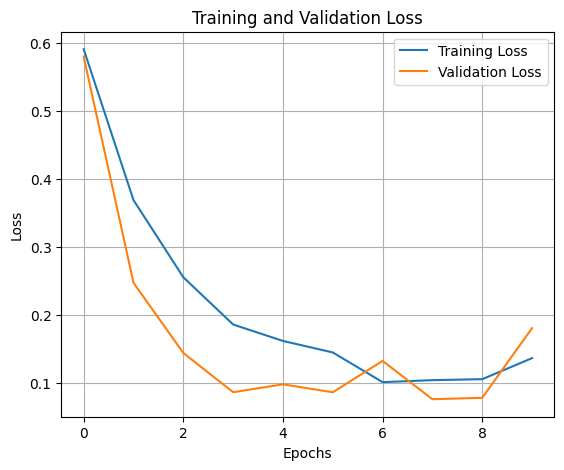

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc
from tensorflow.keras.optimizers import SGD

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Definindo o otimizador SGD com parâmetros opcionais
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e armazenamento do histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Salvando o modelo treinado
model.save("/content/lstm_modelPLOTTEDSGD.h5")
print("Modelo salvo como lstm_model.h5")

# Plotando o histórico de treinamento
plot_history(history)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import RMSprop

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Definindo o otimizador RMSprop
rmsprop_optimizer = RMSprop(learning_rate=0.001, rho=0.9)

# Compilando o modelo com RMSprop
model.compile(optimizer=rmsprop_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e armazenamento do histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Salvando o modelo treinado
model.save("/content/lstm_modelPLOTTEDSGD.h5")
print("Modelo salvo como lstm_model.h5")

# Plotando o histórico de treinamento
plot_history(history)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


114/499 ━━━━━━━━━━━━━━━━━━━━ 5:04 792ms/step - accuracy: 0.6864 - loss: 0.5944

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 1
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com LSTM bidirecional
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e salvando o histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Salvando o modelo no Google Drive
model.save('/content/drive/MyDrive/GRAPHSmeu_modelo_lstm_bidirecional60EPOCHSGRAPH.h5')

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, predictions)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1 = evaluate_model(test_generator, y_test)

# Exibindo métricas
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test Precision: {precision:.2f}')
print(f'Test Sensitivity (Recall): {sensitivity:.2f}')
print(f'Test Specificity: {specificity:.2f}')
print(f'Test F1 Score: {f1:.2f}')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 377s 732ms/step - accuracy: 0.7847 - loss: 0.4418 - val_accuracy: 0.8845 - val_loss: 0.2784


63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step
Test Accuracy: 88.26%
Test Precision: 0.98
Test Sensitivity (Recall): 0.79
Test Specificity: 0.58
Test F1 Score: 0.88


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 60
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com LSTM bidirecional
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e salvando o histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Salvando o modelo no Google Drive
model.save('/content/drive/MyDrive/GRAPHSmeu_modelo_lstm_bidirecional60EPOCHSGRAPH.h5')

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, predictions)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1 = evaluate_model(test_generator, y_test)

# Exibindo métricas
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test Precision: {precision:.2f}')
print(f'Test Sensitivity (Recall): {sensitivity:.2f}')
print(f'Test Specificity: {specificity:.2f}')
print(f'Test F1 Score: {f1:.2f}')


Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 376s 738ms/step - accuracy: 0.7430 - loss: 0.5168 - val_accuracy: 0.9056 - val_loss: 0.2239
Epoch 2/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 382s 738ms/step - accuracy: 0.9143 - loss: 0.1995 - val_accuracy: 0.9237 - val_loss: 0.2134
Epoch 3/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 371s 743ms/step - accuracy: 0.9215 - loss: 0.2136 - val_accuracy: 0.9458 - val_loss: 0.2097
Epoch 4/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 369s 740ms/step - accuracy: 0.9383 - loss: 0.1663 - val_accuracy: 0.9669 - val_loss: 0.0865
Epoch 5/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 380s 737ms/step - accuracy: 0.9672 - loss: 0.0909 - val_accuracy: 0.9618 - val_loss: 0.0861
Epoch 6/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 368s 738ms/step - accuracy: 0.9500 - loss: 0.1260 - val_accuracy: 0.9759 - val_loss: 0.0817
Epoch 7/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 367s 735ms/step - accuracy: 0.9757 - loss: 0.0737 - val_accuracy: 0.9669 - val_loss: 0.0783
Epoch 8/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 384s 739ms/step - accuracy: 0.9737 - loss: 0.06

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 60
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com LSTM bidirecional
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e salvando o histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Salvando o modelo no Google Drive
model.save('/content/drive/MyDrive/GRAPHSmeu_modelo_lstm_bidirecional60EPOCHSGRAPH.h5')

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, predictions)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1 = evaluate_model(test_generator, y_test)

# Exibindo métricas
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test Precision: {precision:.2f}')
print(f'Test Sensitivity (Recall): {sensitivity:.2f}')
print(f'Test Specificity: {specificity:.2f}')
print(f'Test F1 Score: {f1:.2f}')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 393s 753ms/step - accuracy: 0.8384 - loss: 0.3692 - val_accuracy: 0.9558 - val_loss: 0.1691
Epoch 2/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 370s 732ms/step - accuracy: 0.9534 - loss: 0.1424 - val_accuracy: 0.9478 - val_loss: 0.1140
Epoch 3/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 358s 717ms/step - accuracy: 0.9407 - loss: 0.1413 - val_accuracy: 0.9739 - val_loss: 0.0796
Epoch 4/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 382s 719ms/step - accuracy: 0.9413 - loss: 0.1381 - val_accuracy: 0.9799 - val_loss: 0.0567
Epoch 5/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 382s 766ms/step - accuracy: 0.9581 - loss: 0.1149 - val_accuracy: 0.9839 - val_loss: 0.0509
Epoch 6/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 354s 710ms/step - accuracy: 0.9741 - loss: 0.0775 - val_accuracy: 0.9749 - val_loss: 0.0773
Epoch 7/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 386s 718ms/step - accuracy: 0.9686 - loss: 0.0921 - val_accuracy: 0.9809 - val_loss: 0.0465
Epoch 8/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 375s 705ms/step - accuracy: 0.9776 - loss: 0.05

In [ ]:
#BILSTM60EPOCHSRIGHTFINAL

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 60
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

from tensorflow.keras.layers import Bidirectional, LSTM

# Construção do modelo RNN com Bi-LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),  # Primeira camada Bi-LSTM
    Dropout(0.2),
    Bidirectional(LSTM(32)),  # Segunda camada Bi-LSTM
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função corrigida para calcular métricas de avaliação com precisão de 4 casas decimais e padronização de 0 a 1
def evaluate_model(generator, y_true):
    # Gera previsões
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int).flatten()  # Transforma em array 1D

    # Exibe o tamanho dos dados em predictions e y_true
    print(f'Quantidade de previsões (predictions): {len(predictions)}')
    print(f'Quantidade de valores verdadeiros (y_true): {len(y_true)}')

    # Calcula TP, TN, FP, FN
    tp = np.sum((y_true == 1) & (predictions == 1))
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    fn = np.sum((y_true == 1) & (predictions == 0))

    # Métricas de classificação
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Retorna as métricas com precisão de 4 casas decimais
    return (round(accuracy, 4), round(precision, 4), round(recall, 4),
            round(specificity, 4), round(f1, 4), tp, tn, fp, fn)

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1, tp, tn, fp, fn = evaluate_model(test_generator, y_test)

# Exibindo as métricas
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Sensitivity (Recall): {sensitivity:.4f}')
print(f'Test Specificity: {specificity:.4f}')
print(f'Test F1-Score: {f1:.4f}')
print(f'True Positives: {tp}')
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 397s 777ms/step - accuracy: 0.7990 - loss: 0.4393 - val_accuracy: 0.8916 - val_loss: 0.2685
Epoch 2/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 440s 774ms/step - accuracy: 0.9297 - loss: 0.1883 - val_accuracy: 0.9096 - val_loss: 0.2226
Epoch 3/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 446s 783ms/step - accuracy: 0.9169 - loss: 0.1995 - val_accuracy: 0.9709 - val_loss: 0.0631
Epoch 4/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 440s 779ms/step - accuracy: 0.9522 - loss: 0.1126 - val_accuracy: 0.9679 - val_loss: 0.0619
Epoch 5/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 439s 772ms/step - accuracy: 0.9747 - loss: 0.0661 - val_accuracy: 0.9880 - val_loss: 0.0405
Epoch 6/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 441s 771ms/step - accuracy: 0.9709 - loss: 0.0856 - val_accuracy: 0.9267 - val_loss: 0.2077
Epoch 7/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 443s 772ms/step - accuracy: 0.9326 - loss: 0.1923 - val_accuracy: 0.9448 - val_loss: 0.1396
Epoch 8/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 443s 774ms/step - accuracy: 0.9470 - loss: 0.14

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 30
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com Bi-LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),  # Primeira camada Bi-LSTM com mais unidades
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),  # Segunda camada Bi-LSTM para capturar mais padrões
    Dropout(0.2),
    Bidirectional(LSTM(32)),  # Terceira camada Bi-LSTM para refinar padrões aprendidos
    Dropout(0.2),
    Dense(128, activation='relu'),  # Camada Dense maior para maior capacidade de aprendizado
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para calcular métricas de avaliação com precisão de 4 casas decimais
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int).flatten()

    tp = np.sum((y_true == 1) & (predictions == 1))
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    fn = np.sum((y_true == 1) & (predictions == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return (round(accuracy, 4), round(precision, 4), round(recall, 4),
            round(specificity, 4), round(f1, 4), tp, tn, fp, fn)

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1, tp, tn, fp, fn = evaluate_model(test_generator, y_test)

# Exibindo as métricas
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Sensitivity (Recall): {sensitivity:.4f}')
print(f'Test Specificity: {specificity:.4f}')
print(f'Test F1-Score: {f1:.4f}')
print(f'True Positives: {tp}')
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')


Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 694s 1s/step - accuracy: 0.8079 - loss: 0.4286 - val_accuracy: 0.9538 - val_loss: 0.1401
Epoch 2/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - accuracy: 0.9183 - loss: 0.2100 - val_accuracy: 0.9548 - val_loss: 0.1382
Epoch 3/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 684s 1s/step - accuracy: 0.9577 - loss: 0.1157 - val_accuracy: 0.9789 - val_loss: 0.0712
Epoch 4/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 684s 1s/step - accuracy: 0.9755 - loss: 0.0760 - val_accuracy: 0.9809 - val_loss: 0.0805
Epoch 5/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 694s 1s/step - accuracy: 0.9786 - loss: 0.0728 - val_accuracy: 0.9819 - val_loss: 0.0603
Epoch 6/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - accuracy: 0.9840 - loss: 0.0589 - val_accuracy: 0.9699 - val_loss: 0.0880
Epoch 7/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - accuracy: 0.9861 - loss: 0.0509 - val_accuracy: 0.9880 - val_loss: 0.0419
Epoch 8/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 668s 1s/step - accuracy: 0.9909 - loss: 0.0341 - val_accuracy: 0.982

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 30
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com Bi-LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),  # Primeira camada Bi-LSTM com mais unidades
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),  # Segunda camada Bi-LSTM para capturar mais padrões
    Dropout(0.2),
    Bidirectional(LSTM(32)),  # Terceira camada Bi-LSTM para refinar padrões aprendidos
    Dropout(0.2),
    Dense(128, activation='relu'),  # Camada Dense maior para maior capacidade de aprendizado
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para calcular métricas de avaliação com precisão de 4 casas decimais
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int).flatten()

    tp = np.sum((y_true == 1) & (predictions == 1))
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    fn = np.sum((y_true == 1) & (predictions == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return (round(accuracy, 4), round(precision, 4), round(recall, 4),
            round(specificity, 4), round(f1, 4), tp, tn, fp, fn)

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1, tp, tn, fp, fn = evaluate_model(test_generator, y_test)

# Exibindo as métricas
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Sensitivity (Recall): {sensitivity:.4f}')
print(f'Test Specificity: {specificity:.4f}')
print(f'Test F1-Score: {f1:.4f}')
print(f'True Positives: {tp}')
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')


Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 718s 1s/step - accuracy: 0.7379 - loss: 0.5145 - val_accuracy: 0.8896 - val_loss: 0.3366
Epoch 2/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - accuracy: 0.9078 - loss: 0.2888 - val_accuracy: 0.8775 - val_loss: 0.3080
Epoch 3/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 696s 1s/step - accuracy: 0.8624 - loss: 0.3027 - val_accuracy: 0.9408 - val_loss: 0.1721
Epoch 4/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 733s 1s/step - accuracy: 0.9024 - loss: 0.2381 - val_accuracy: 0.8835 - val_loss: 0.2810
Epoch 5/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 688s 1s/step - accuracy: 0.8987 - loss: 0.2412 - val_accuracy: 0.9398 - val_loss: 0.1444
Epoch 6/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 696s 1s/step - accuracy: 0.9491 - loss: 0.1359 - val_accuracy: 0.9307 - val_loss: 0.1739
Epoch 7/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 697s 1s/step - accuracy: 0.9649 - loss: 0.0928 - val_accuracy: 0.9759 - val_loss: 0.0843
Epoch 8/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 696s 1s/step - accuracy: 0.9740 - loss: 0.0821 - val_accuracy: 0.963

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.utils import Sequence
import gc
import os
from google.colab import drive

# Montando o Google Drive
drive.mount('/content/drive')

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 30
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com Bi-LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para calcular métricas de avaliação com precisão de 4 casas decimais
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int).flatten()

    tp = np.sum((y_true == 1) & (predictions == 1))
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    fn = np.sum((y_true == 1) & (predictions == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return (round(accuracy, 4), round(precision, 4), round(recall, 4),
            round(specificity, 4), round(f1, 4), tp, tn, fp, fn)

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1, tp, tn, fp, fn = evaluate_model(test_generator, y_test)

# Exibindo as métricas
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Sensitivity (Recall): {sensitivity:.4f}')
print(f'Test Specificity: {specificity:.4f}')
print(f'Test F1-Score: {f1:.4f}')
print(f'True Positives: {tp}')
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')

# Salvar o modelo no Google Drive
model_save_path = "/content/drive/MyDrive/modelo_bi_lstm.h5"
model.save(model_save_path)

# Salvar as métricas em um arquivo CSV
metrics = {
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Sensitivity': [sensitivity],
    'Specificity': [specificity],
    'F1-Score': [f1],
    'True Positives': [tp],
    'True Negatives': [tn],
    'False Positives': [fp],
    'False Negatives': [fn]
}

metrics_df = pd.DataFrame(metrics)
metrics_save_path = "/content/drive/MyDrive/metricas_avaliacao30EPOCHS.csv"
metrics_df.to_csv(metrics_save_path, index=False)

print(f'Modelo salvo em: {model_save_path}')
print(f'Métricas salvas em: {metrics_save_path}')


Mounted at /content/drive


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 795s 2s/step - accuracy: 0.7544 - loss: 0.5224 - val_accuracy: 0.8906 - val_loss: 0.2671
Epoch 2/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 774s 2s/step - accuracy: 0.9007 - loss: 0.2912 - val_accuracy: 0.7992 - val_loss: 0.5482
Epoch 3/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 747s 1s/step - accuracy: 0.9394 - loss: 0.1977 - val_accuracy: 0.9749 - val_loss: 0.0748
Epoch 4/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 808s 2s/step - accuracy: 0.9628 - loss: 0.1125 - val_accuracy: 0.9508 - val_loss: 0.1491
Epoch 5/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 749s 2s/step - accuracy: 0.9500 - loss: 0.1371 - val_accuracy: 0.9799 - val_loss: 0.0539
Epoch 6/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 751s 2s/step - accuracy: 0.9826 - loss: 0.0560 - val_accuracy: 0.9839 - val_loss: 0.0541
Epoch 7/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 808s 2s/step - accuracy: 0.9806 - loss: 0.0664 - val_accuracy: 0.9890 - val_loss: 0.0401
Epoch 8/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 802s 2s/step - accuracy: 0.9834 - loss: 0.0561 - val_accuracy: 0.982

Test Accuracy: 0.9980
Test Precision: 0.9981
Test Sensitivity (Recall): 0.9981
Test Specificity: 0.9979
Test F1-Score: 0.9981
True Positives: 516
True Negatives: 479
False Positives: 1
False Negatives: 1
Modelo salvo em: /content/drive/MyDrive/modelo_bi_lstm.h5
Métricas salvas em: /content/drive/MyDrive/metricas_avaliacao30EPOCHS.csv


In [ ]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt

# Parameters
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 30
random_state = 42

# File paths
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Initializing the tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processing CSV files in chunks for training
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenizing and padding sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Splitting data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# LSTM model
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(32, return_sequences=True),  # First LSTM layer
    Dropout(0.2),
    LSTM(32),  # Second LSTM layer
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Data Generator class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Creating data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Model training
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Function to calculate evaluation metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int).flatten()

    tp = np.sum((y_true == 1) & (predictions == 1))
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    fn = np.sum((y_true == 1) & (predictions == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = 2 * (precision * recall) / (precision + recall)
    return (round(accuracy, 4), round(precision, 4), round(recall, 4),
            round(specificity, 4), round(f1, 4), tp, tn, fp, fn)

# Evaluation on the test set
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1, tp, tn, fp, fn = evaluate_model(test_generator, y_test)

# Display metrics
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Sensitivity (Recall): {sensitivity:.4f}')
print(f'Test Specificity: {specificity:.4f}')
print(f'Test F1-Score: {f1:.4f}')
print(f'True Positives: {tp}')
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')


Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 232s 449ms/step - accuracy: 0.6457 - loss: 0.6349 - val_accuracy: 0.6817 - val_loss: 0.5640
Epoch 2/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 228s 381ms/step - accuracy: 0.6782 - loss: 0.5663 - val_accuracy: 0.6827 - val_loss: 0.5646
Epoch 3/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 187s 375ms/step - accuracy: 0.6712 - loss: 0.5714 - val_accuracy: 0.6777 - val_loss: 0.5778
Epoch 4/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 201s 373ms/step - accuracy: 0.6609 - loss: 0.5767 - val_accuracy: 0.6817 - val_loss: 0.5616
Epoch 5/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 207s 383ms/step - accuracy: 0.6703 - loss: 0.5672 - val_accuracy: 0.6827 - val_loss: 0.5616
Epoch 6/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 200s 380ms/step - accuracy: 0.6800 - loss: 0.5643 - val_accuracy: 0.6817 - val_loss: 0.5574
Epoch 7/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 201s 378ms/step - accuracy: 0.6609 - loss: 0.5764 - val_accuracy: 0.6707 - val_loss: 0.5771
Epoch 8/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 205s 383ms/step - accuracy: 0.6749 - loss: 0.56